## Configuration

In [1]:
# Installs and imports

from pathlib import Path
import json
import os
import sys
import subprocess

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Install requirements without relying on IPython magic variable substitution.
# Run quietly and suppress output.
subprocess.run(
	[sys.executable, "-m", "pip", "install", "-r", str(PROJECT_ROOT / "requirements.txt"), "-q"],
	check=True,
	stdout=subprocess.DEVNULL,
	stderr=subprocess.STDOUT,
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid", palette="deep")
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "widsdatathon2020"
sys.path.append(str(PROJECT_ROOT))



# WiDS Datathon 2020 ICU Data

This notebook downloads the Kaggle competition files into `data/raw/widsdatathon2020` and starts a lightweight EDA pass for ICU mortality modeling.

## Kaggle Authentication and Data Download

The cleanest local setup is to use Kaggle's `kaggle.json` API token file instead of typing credentials into the notebook.

1. In Kaggle, click on your **Account picture** and choose `your API tokens`.
2. Click on `Create Legacy API token`, this should download a file called `kaggle.json`.
3. Create a local folder named `secrets` in this project and place the downloaded file in it.
4. Keep `secrets/` out of git. The notebook reads the JSON file, sets `KAGGLE_USERNAME` and `KAGGLE_KEY` only for this Python session, and then KaggleHub can download the competition data.

If your token file is somewhere else, update `KAGGLE_JSON_PATH` in the next cell.

In [2]:
# Kaggle authentication from kaggle.json
KAGGLE_JSON_PATH = PROJECT_ROOT / "secrets" / "kaggle.json"

if not KAGGLE_JSON_PATH.exists():
    raise FileNotFoundError(
        f"Kaggle credentials file not found: {KAGGLE_JSON_PATH}\n"
        "Download kaggle.json from Kaggle Account settings, save it there, "
        "or update KAGGLE_JSON_PATH to its actual location."
    )

with KAGGLE_JSON_PATH.open(encoding="utf-8") as credentials_file:
    kaggle_credentials = json.load(credentials_file)

KAGGLE_USERNAME = kaggle_credentials.get("username")
KAGGLE_KEY = kaggle_credentials.get("key")

if not KAGGLE_USERNAME or not KAGGLE_KEY:
    raise ValueError("kaggle.json must contain both 'username' and 'key'.")

os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
os.environ["KAGGLE_KEY"] = KAGGLE_KEY

print(f"Kaggle credentials loaded for user: {KAGGLE_USERNAME}")


Kaggle credentials loaded for user: omriavital


In [3]:
from scripts.download_wids_data import download_wids_data

download_wids_data(
    DATA_DIR,
    kaggle_json=KAGGLE_JSON_PATH,
)
sorted(path.name for path in DATA_DIR.iterdir())


Data already exists at: /mnt/new_groups/assafza_group/assafza/Denis/MedicalRiskModel/data/raw/widsdatathon2020
Use --force to download again and overwrite copied files.


['WiDS Datathon 2020 Dictionary.csv',
 'samplesubmission.csv',
 'solution_template.csv',
 'training_v2.csv',
 'unlabeled.csv']

In [4]:
csv_files = sorted(DATA_DIR.glob("*.csv"))
csv_files


[PosixPath('/mnt/new_groups/assafza_group/assafza/Denis/MedicalRiskModel/data/raw/widsdatathon2020/WiDS Datathon 2020 Dictionary.csv'),
 PosixPath('/mnt/new_groups/assafza_group/assafza/Denis/MedicalRiskModel/data/raw/widsdatathon2020/samplesubmission.csv'),
 PosixPath('/mnt/new_groups/assafza_group/assafza/Denis/MedicalRiskModel/data/raw/widsdatathon2020/solution_template.csv'),
 PosixPath('/mnt/new_groups/assafza_group/assafza/Denis/MedicalRiskModel/data/raw/widsdatathon2020/training_v2.csv'),
 PosixPath('/mnt/new_groups/assafza_group/assafza/Denis/MedicalRiskModel/data/raw/widsdatathon2020/unlabeled.csv')]

## Data View

In [5]:
train_path = DATA_DIR / "training_v2.csv"
if not train_path.exists():
    train_path = next((path for path in csv_files if "train" in path.name.lower()), None)

if train_path is None:
    raise FileNotFoundError(f"Could not find a training CSV in {DATA_DIR}")

df = pd.read_csv(train_path)
print(df.shape)
df.head()


(91713, 186)


,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,hospital_admit_source,icu_admit_source,icu_id,icu_stay_type,icu_type,pre_icu_los_days,readmission_status,weight,albumin_apache,apache_2_diagnosis,apache_3j_diagnosis,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,paco2_for_ph_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_invasive_max,d1_diasbp_invasive_min,d1_diasbp_max,d1_diasbp_min,d1_diasbp_noninvasive_max,d1_diasbp_noninvasive_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_invasive_max,d1_mbp_invasive_min,d1_mbp_max,d1_mbp_min,d1_mbp_noninvasive_max,d1_mbp_noninvasive_min,...,d1_wbc_max,d1_wbc_min,h1_albumin_max,h1_albumin_min,h1_bilirubin_max,h1_bilirubin_min,h1_bun_max,h1_bun_min,h1_calcium_max,h1_calcium_min,h1_creatinine_max,h1_creatinine_min,h1_glucose_max,h1_glucose_min,h1_hco3_max,h1_hco3_min,h1_hemaglobin_max,h1_hemaglobin_min,h1_hematocrit_max,h1_hematocrit_min,h1_inr_max,h1_inr_min,h1_lactate_max,h1_lactate_min,h1_platelets_max,h1_platelets_min,h1_potassium_max,h1_potassium_min,h1_sodium_max,h1_sodium_min,h1_wbc_max,h1_wbc_min,d1_arterial_pco2_max,d1_arterial_pco2_min,d1_arterial_ph_max,d1_arterial_ph_min,d1_arterial_po2_max,d1_arterial_po2_min,d1_pao2fio2ratio_max,d1_pao2fio2ratio_min,h1_arterial_pco2_max,h1_arterial_pco2_min,h1_arterial_ph_max,h1_arterial_ph_min,h1_arterial_po2_max,h1_arterial_po2_min,h1_pao2fio2ratio_max,h1_pao2fio2ratio_min,apache_4a_hospital_death_prob,apache_4a_icu_death_prob,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,66154,25312,118,0,68.0,22.73,0,Caucasian,M,180.3,Floor,Floor,92,admit,CTICU,0.541667,0,73.9,2.3,113.0,502.01,0,0.0,0.4,31.0,2.51,NaN,3.0,6.0,0.0,4.0,168.0,118.0,27.4,0.0,40.0,NaN,NaN,NaN,NaN,36.0,134.0,39.3,NaN,0.0,14.1,46.0,32.0,68.0,37.0,68.0,37.0,119.0,72.0,66.0,40.0,89.0,46.0,89.0,46.0,...,14.1,14.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.10,0.05,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,114252,59342,81,0,77.0,27.42,0,Caucasian,F,160.0,Floor,Floor,90,admit,Med-Surg ICU,0.927778,0,70.2,NaN,108.0,203.01,0,0.0,NaN,9.0,0.56,1.0,1.0,3.0,0.0,1.0,145.0,120.0,36.9,0.0,46.0,37.0,37.0,51.0,7.45,33.0,145.0,35.1,NaN,1.0,12.7,NaN,NaN,95.0,31.0,95.0,31.0,118.0,72.0,NaN,NaN,120.0,38.0,120.0,38.0,...,23.3,12.7,NaN,NaN,NaN,NaN,9.0,9.0,8.6,8.6,0.56,0.56,145.0,143.0,27.0,27.0,11.3,11.3,36.9,36.9,1.3,1.3,3.5,3.5,557.0,557.0,4.2,4.2,145.0,145.0,12.7,12.7,37.0,37.0,7.45,7.45,51.0,51.0,54.8,51.000000,37.0,37.0,7.45,7.45,51.0,51.0,51.0,51.0,0.47,0.29,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory
2,119783,50777,118,0,25.0,31.95,0,Caucasian,F,172.7,Emergency Department,Accident & Emergency,93,admit,Med-Surg ICU,0.000694,0,95.3,NaN,122.0,703.03,0,0.0,NaN,NaN,NaN,NaN,3.0,6.0,0.0,5.0,NaN,102.0,NaN,0.0,68.0,NaN,NaN,NaN,NaN,37.0,NaN,36.7,NaN,0.0,NaN,NaN,NaN,88.0,48.0,88.0,48.0,96.0,68.0,NaN,NaN,102.0,68.0,102.0,68.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic
3,79267,46918,118,0,81.0,22.64,1,Caucasian,F,165.1,Operating Room,Operating Room / Recovery,92,admit,CTICU,0.000694,0,61.7,NaN,203.0,1206.03,1,0.0,NaN,NaN,NaN,0.6,4.0,6.0,0.0,5.0,185.0,114.0,25.9,1.0,60.0,30.0,30.0,142.0,7.39,4.0,NaN,34.8,NaN,1.0,8.0,62.0,30.0,48.0,42.0,48.0,42.0,116.0,92.0,92.0,52.0,84.0,84.0,84.0,84.0,...,9.0,8.0

Gender column is a string (M/F) yet it can be binary (0/1) instead.

In [6]:
df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 91713 entries, 0 to 91712
Columns: 186 entries, encounter_id to apache_2_bodysystem
dtypes: float64(170), int64(8), str(8)
memory usage: 130.1 MB


91713 instances and 185 features

In [7]:
target_col = "hospital_death"
if target_col in df.columns:
    display(df[target_col].value_counts(dropna=False).rename("count").to_frame())
    display(df[target_col].value_counts(normalize=True, dropna=False).rename("rate").to_frame())
else:
    print(f"Target column {target_col!r} not found.")


,count
hospital_death,
0,83798
1,7915


,rate
hospital_death,
0,0.913698
1,0.086302


Big imbalance of target prediction need to be dealt with downstream

In [15]:
missing = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .to_frame()
)
missing.head(20)


,missing_rate
h1_bilirubin_min,0.922650
h1_bilirubin_max,0.922650
h1_lactate_max,0.919924
h1_lactate_min,0.919924
h1_albumin_max,0.913982
h1_albumin_min,0.913982
h1_pao2fio2ratio_min,0.874413
h1_pao2fio2ratio_max,0.874413
h1_arterial_ph_max,0.833295
h1_arterial_ph_min,0.833295


Many of the features are missing 

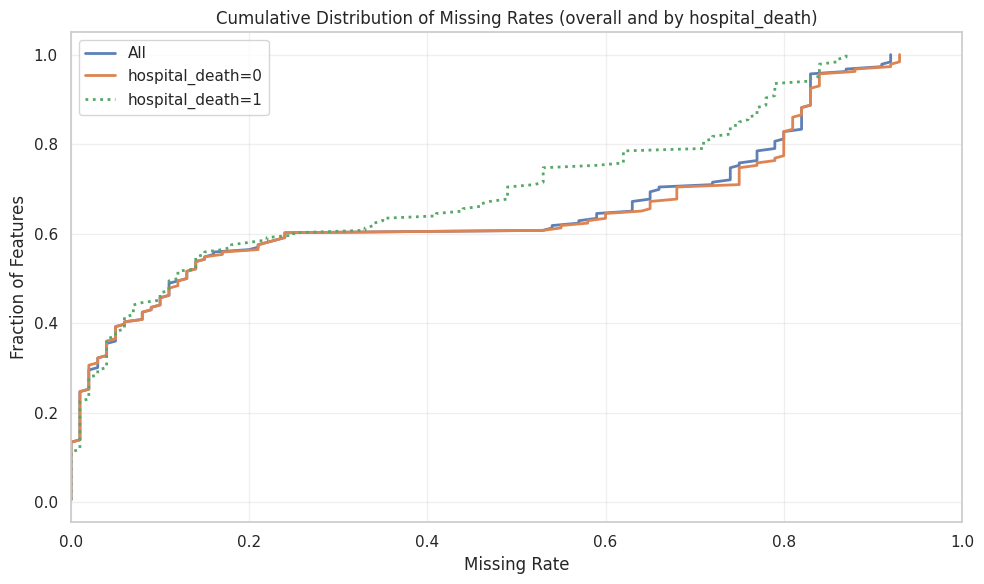

In [18]:
plt.figure(figsize=(10, 6))

# Overall missing-rate CDF
missing_rates_all = np.sort(np.round(missing["missing_rate"].to_numpy(), 2))

# CDF baseline
cdf = np.arange(1, len(missing_rates_all) + 1) / len(missing_rates_all)

# Plot overall
plt.plot(missing_rates_all, cdf, linestyle="-", linewidth=2, label="All", alpha=0.9)

# If target exists, compute and plot missing-rate CDFs for each class
if target_col in df.columns:
    missing_by_class = {}
    for cls in [0, 1]:
        sub = df[df[target_col] == cls]
        # ensure same length (features) ordering matches overall by sorting
        missing_by_class[cls] = np.sort(np.round(sub.isna().mean().to_numpy(), 2))

    plt.plot(missing_by_class[0], cdf, linestyle="-", linewidth=2, label=f"{target_col}=0")
    plt.plot(missing_by_class[1], cdf, linestyle=":", linewidth=2, label=f"{target_col}=1")

plt.xlabel("Missing Rate")
plt.ylabel("Fraction of Features")
plt.title("Cumulative Distribution of Missing Rates (overall and by hospital_death)")
plt.xlim(0, 1)
#plt.xticks(np.arange(0, 1.01, 0.05))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The plateau in the graph shows a "sweet spot" cutoff of featues that have too many missing values 

In [10]:
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols].describe().T.sort_values("std", ascending=False).head(30)


,count,mean,std,min,25%,50%,75%,max
patient_id,91713.0,65537.131464,37811.252183,1.000,32830.000000,65413.000000,98298.0000,131051.000000
encounter_id,91713.0,65606.079280,37795.088538,1.000,32852.000000,65665.000000,98342.0000,131051.000000
urineoutput_apache,42715.0,1738.276831,1448.162411,0.000,740.361600,1386.201600,2324.5488,8716.669632
apache_3j_diagnosis,90612.0,558.216377,463.266985,0.010,203.010000,409.020000,703.0300,2201.050000
icu_id,91713.0,508.357692,228.989661,82.000,369.000000,504.000000,679.0000,927.000000
h1_pao2fio2ratio_max,11518.0,244.404982,129.964308,42.000,142.000000,223.333333,328.0000,720.000000
d1_pao2fio2ratio_max,25705.0,285.667079,128.218956,54.800,192.285714,272.666667,365.0000,834.805000
h1_pao2fio2ratio_min,11518.0,235.933050,126.458507,38.000,136.000000,214.000000,317.4750,654.813793
d1_pao2fio2ratio_min,25705.0,223.523037,117.552497,36.000,132.500000,205.000000,300.0000,604.227778
h1_arterial_po2_max,15768.0,163.841354,113.455738,34.000,80.700000,120.000000,216.0000,534.905000


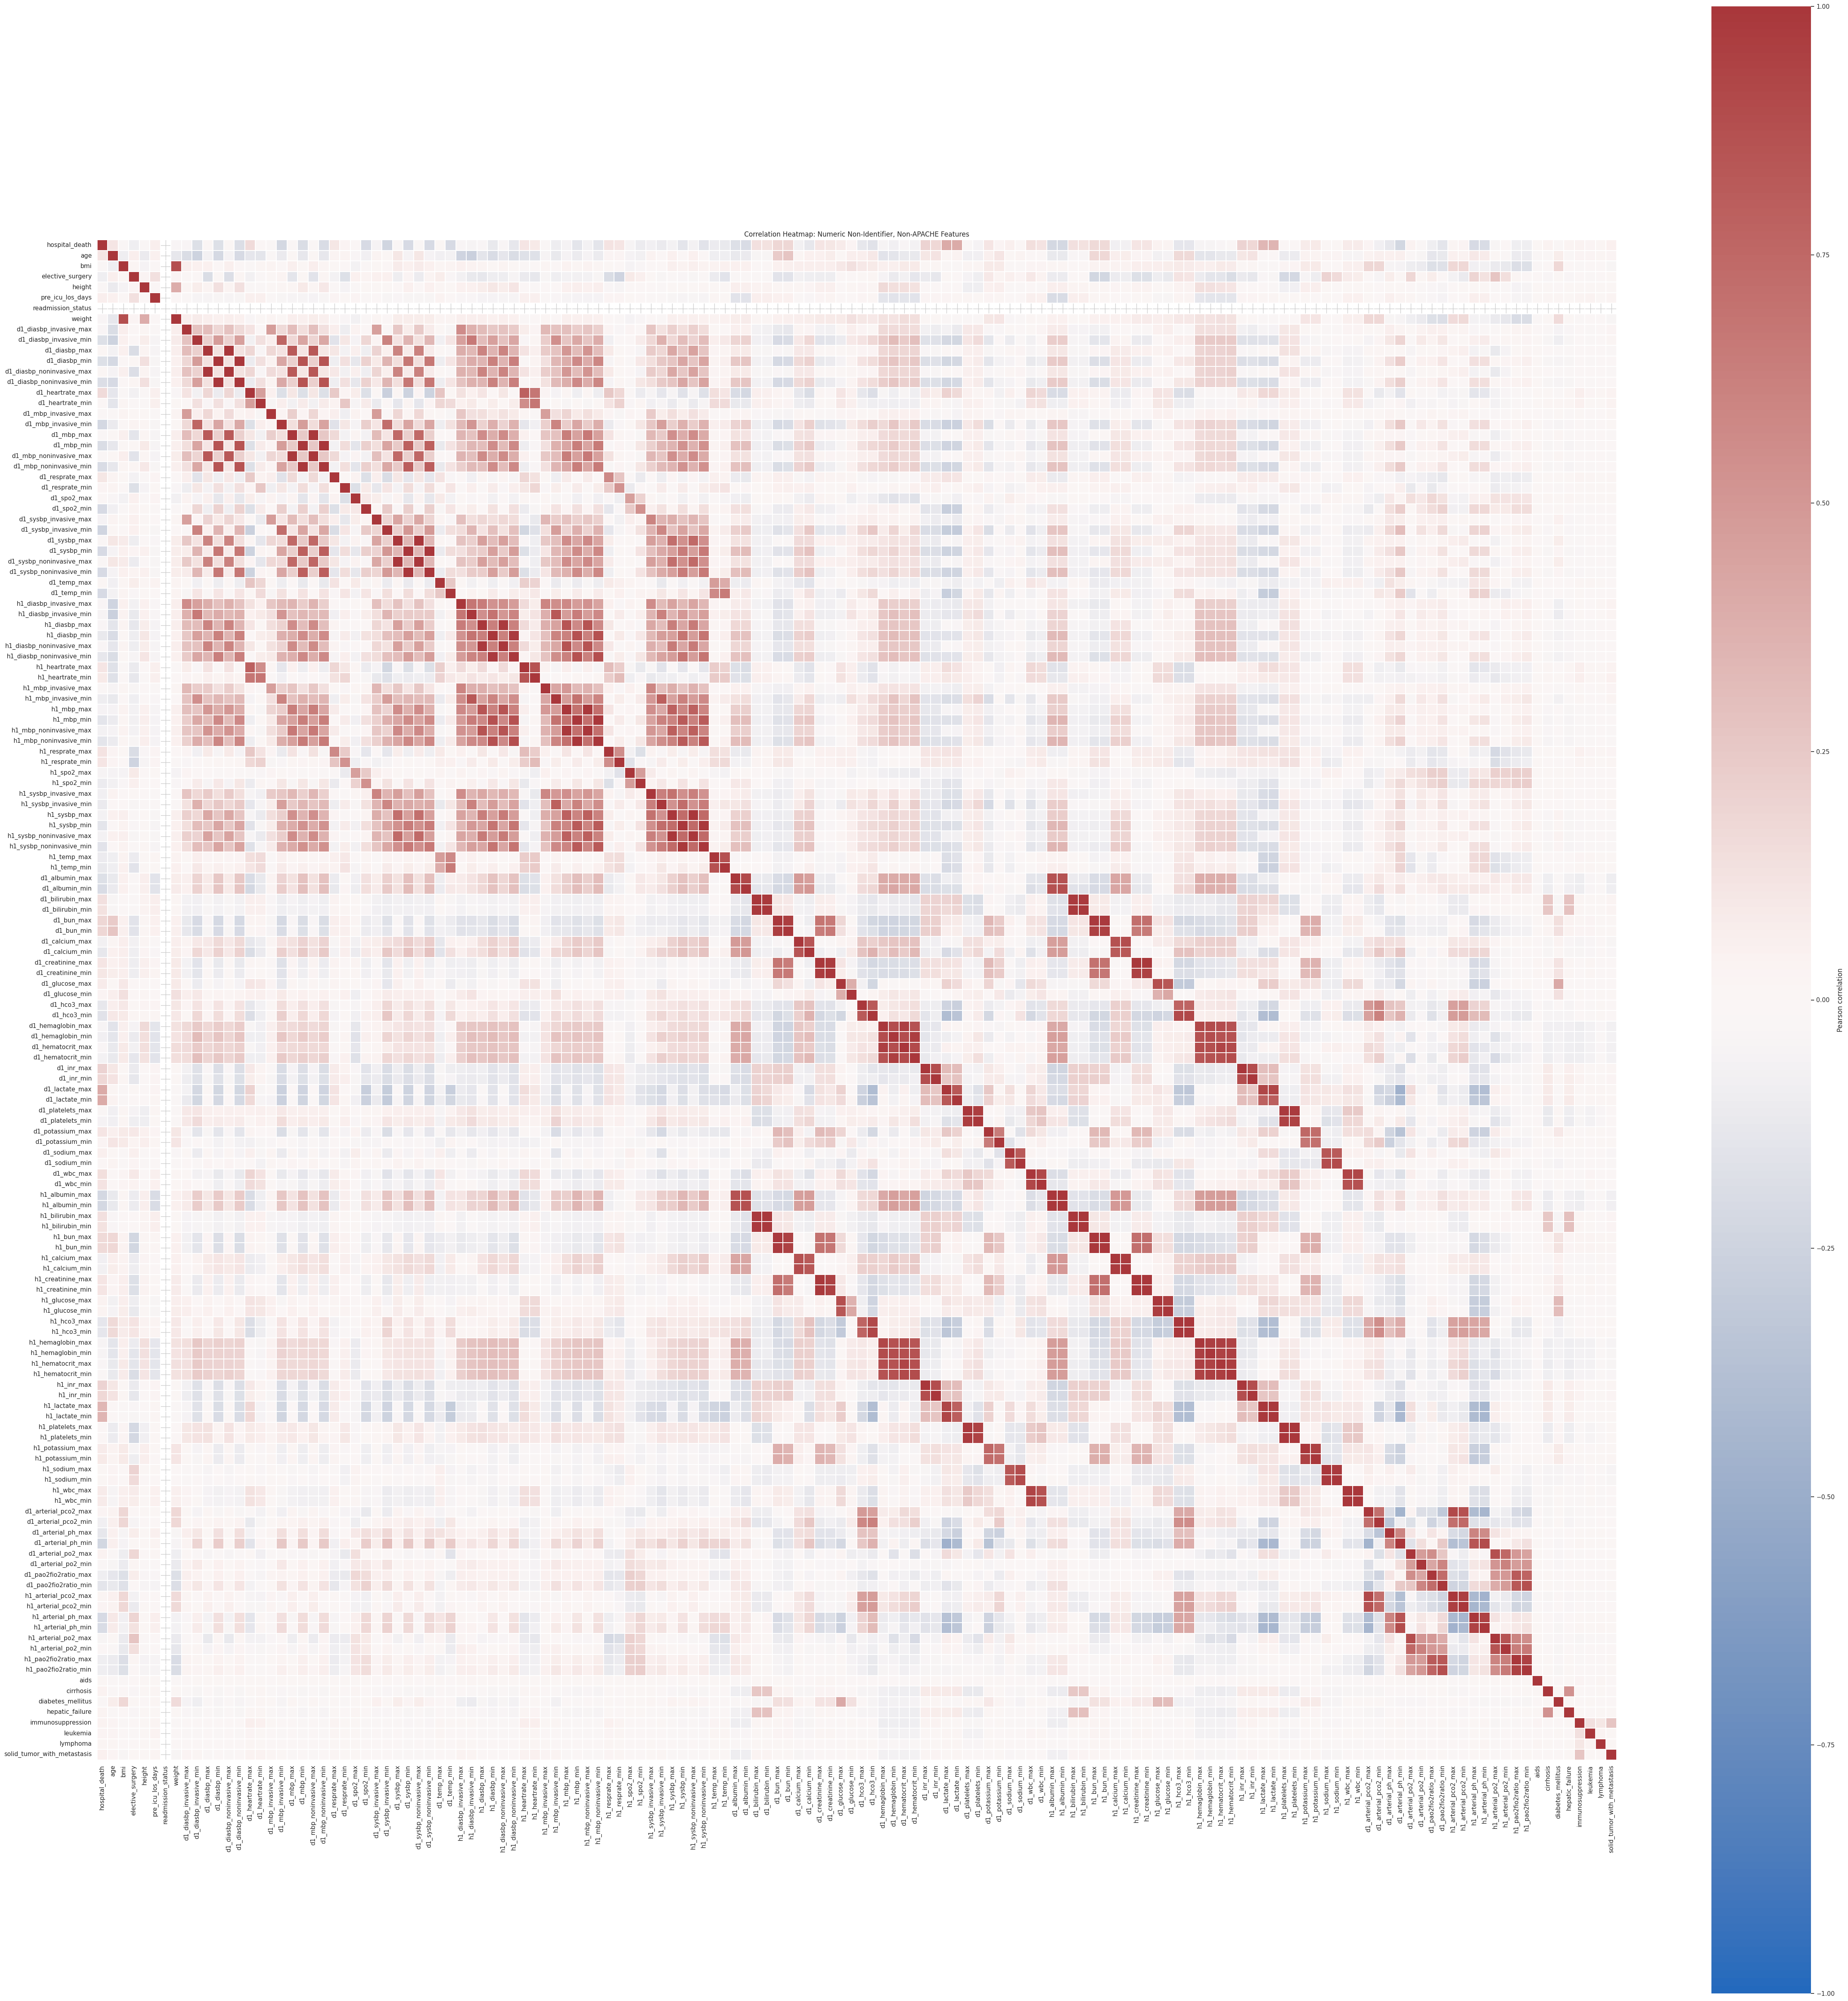

Included 144 numeric features.
Excluded identifier columns: ['encounter_id', 'hospital_id', 'icu_id', 'patient_id']
Excluded APACHE columns: 32


In [11]:
identifier_cols = {
    "encounter_id",
    "patient_id",
    "hospital_id",
    "icu_id",
}

heatmap_cols = [
    col
    for col in df.select_dtypes(include="number").columns
    if col not in identifier_cols and "apache" not in col.lower()
]

corr = df[heatmap_cols].corr(numeric_only=True)

plt.figure(figsize=(max(12, 0.35 * len(corr.columns)), max(10, 0.35 * len(corr.columns))))
sns.heatmap(
    corr,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.1,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Correlation Heatmap: Numeric Non-Identifier, Non-APACHE Features")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Included {len(heatmap_cols)} numeric features.")
print("Excluded identifier columns:", sorted(identifier_cols.intersection(df.columns)))
print("Excluded APACHE columns:", sum("apache" in col.lower() for col in df.columns))


In [20]:
# Print feature pairs with absolute correlation above a threshold (uses `corr` from the heatmap cell)
threshold = 0.8
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pairs = corr.where(mask).stack().reset_index()
pairs.columns = ['feature1', 'feature2', 'corr']
pairs['abs_corr'] = pairs['corr'].abs()
strong = pairs[pairs['abs_corr'] >= threshold].sort_values('abs_corr', ascending=False).reset_index(drop=True)
if strong.empty:
    print(f'No feature pairs with |corr| >= {threshold}')
else:
    display(strong)

# Optionally show top-N pairs: display(strong.head(50))

,feature1,feature2,corr,abs_corr
0,d1_inr_min,h1_inr_min,1.000000,1.000000
1,d1_inr_max,h1_inr_max,1.000000,1.000000
2,h1_bilirubin_max,h1_bilirubin_min,0.999934,0.999934
3,h1_albumin_max,h1_albumin_min,0.999727,0.999727
4,h1_bun_max,h1_bun_min,0.999630,0.999630
...,...,...,...,...
139,d1_pao2fio2ratio_max,h1_pao2fio2ratio_max,0.816347,0.816347
140,d1_sodium_max,h1_sodium_min,0.816206,0.816206
141,h1_mbp_min,h1_sysbp_noninvasive_min,0.816024,0.816024
142,d1_lactate_min,h1_lactate_min,0.803146,0.803146


many of the features are strongly correlated and may cause multi-correlation 

In [12]:
categorical_cols = df.select_dtypes(exclude="number").columns
pd.DataFrame({
    "unique_values": df[categorical_cols].nunique(dropna=True),
    "missing_rate": df[categorical_cols].isna().mean(),
}).sort_values(["missing_rate", "unique_values"], ascending=False).head(30)


,unique_values,missing_rate
hospital_admit_source,15,0.233435
apache_3j_bodysystem,11,0.018122
apache_2_bodysystem,10,0.018122
ethnicity,6,0.015210
icu_admit_source,5,0.001221
gender,2,0.000273
icu_type,8,0.000000
icu_stay_type,3,0.000000


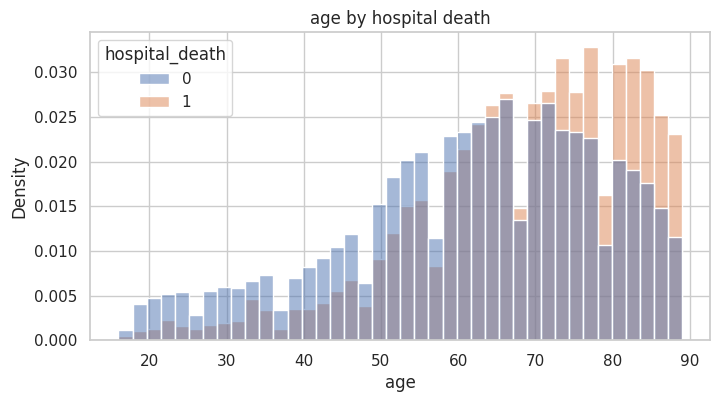

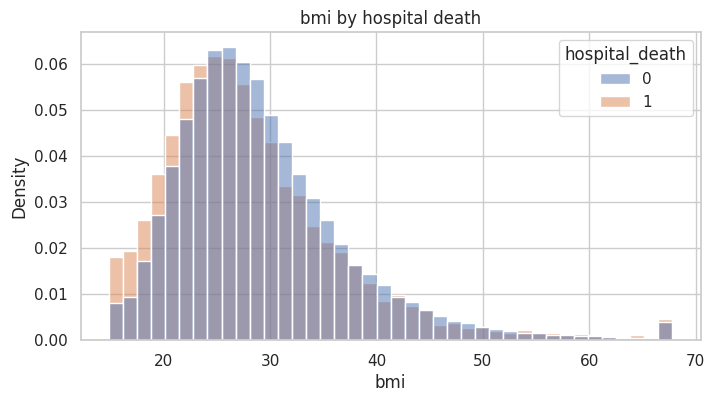

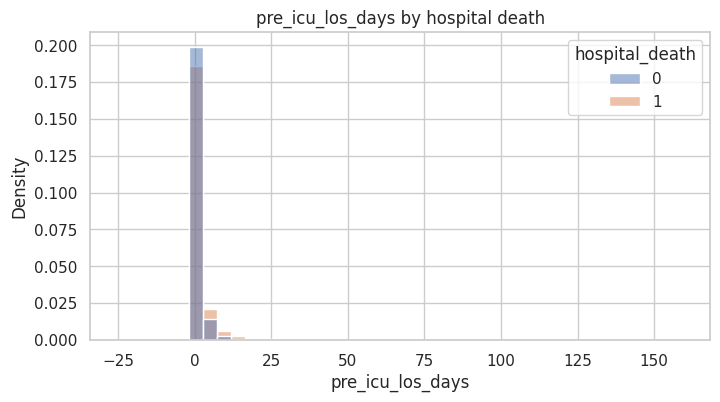

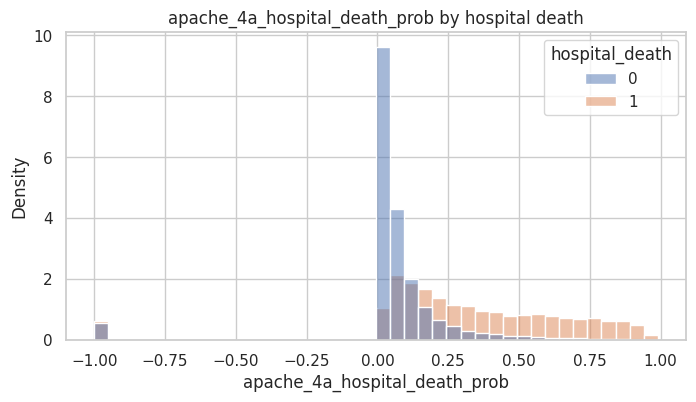

In [13]:
if target_col in df.columns:
    candidate_cols = ["age", "bmi", "pre_icu_los_days", "apache_4a_hospital_death_prob"]
    plot_cols = [col for col in candidate_cols if col in df.columns]
    for col in plot_cols:
        plt.figure(figsize=(8, 4))
        sns.histplot(data=df, x=col, hue=target_col, bins=40, stat="density", common_norm=False)
        plt.title(f"{col} by hospital death")
        plt.show()
